In [4]:
from utils import *
import pandas as pd
import glob, os

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
def safe_map(func):
    def wrapper(x):
        try:
            return func(x)
        except Exception:
            return None

    return wrapper

In [6]:
dfs = []
for file in glob.glob(f"../results/experiment*scaling*.csv"):
    dfs.append(pd.read_csv(file))
df = pd.concat(dfs, ignore_index=True)
for col in df.columns:
    if col.endswith("times"):
        df[col] = df[col].apply(safe_map(ast.literal_eval))
df["metadata"] = df["metadata"].apply(safe_map(ast.literal_eval))
df["solvers m"] = df["solvers m"].apply(lambda m: "-" if pd.isna(m) else m)
df["coarse m"] = df["coarse m"].apply(lambda m: "-" if pd.isna(m) else m)
df["p"] = df["p"].apply(int)

In [7]:
def nice_solver_name(name):
    if "AMGX" in name:
        return "AmgX"
    if "Hybrid" in name:
        return "Hybrid Schwarz"
    if "Additive" in name:
        return "Additive Schwarz"
    return None

In [8]:
df["best solve time"] = df["solve times"].apply(min)
df["best DoFs/s"] = df.apply(
    lambda row: row["DoFs"] / row["best solve time"] * 1000,
    axis=1,
)
df["nice solver"] = df["solver"].apply(nice_solver_name)
df["fine m val"] = df["fine m"].apply(lambda m: int(m[1:]))

In [9]:
pivot = df.pivot_table(
    values="best DoFs/s",
    index=["p", "solver"],
    columns=["DoFs"]
)
pivot

DoFs                                                        5120     \
p solver                                                              
1 AMGX(CG_L1_TRUNC, None)                                       NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)                    NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)                     NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...            NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)            NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...            NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...            NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...            NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...            NaN   
3 AMGX(CG_L1_TRUNC, None)                             420585.564540   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          214081.765562   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)            87029.741112   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  225827.934944   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)   89029.456367   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   89124.571659   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   38358.421534   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  150892.580360   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...   63165.159876   

DoFs                                                        6144     \
p solver                                                              
1 AMGX(CG_L1_TRUNC, None)                             940982.727048   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          452059.342915   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           175987.436874   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  454903.001585   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  183059.371870   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  216802.904754   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   93343.215991   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  378997.977838   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  159869.304056   
3 AMGX(CG_L1_TRUNC, None)                                       NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)                    NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)                     NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...            NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)            NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...            NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...            NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...            NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...            NaN   

DoFs                                                        20480    \
p solver                                                              
1 AMGX(CG_L1_TRUNC, None)                                       NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)                    NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)                     NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...            NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)            NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...            NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...            NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...            NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...            NaN   
3 AMGX(CG_L1_TRUNC, None)                             976724.910691   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          634474.991656   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           301521.703943   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  647163.452101   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  309630.778309   
  CG(AdditiveSchwarz(t

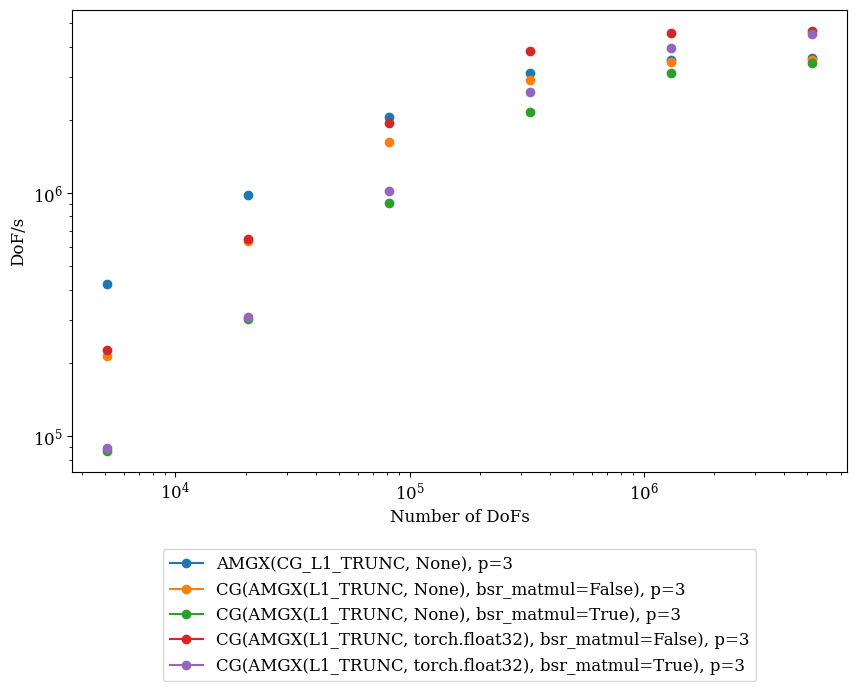

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale("log")
ax.set_xscale("log")
for (p, solver), vals in pivot.iterrows():
    if p != 3:
        continue
    if "AMGX" not in solver:
        continue
    ax.plot(vals, label=f"{solver}, p={p}", marker='o')
ax.set_ylabel("DoF/s")
ax.set_xlabel("Number of DoFs")

#legend below the plot
ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=1)

fig.show()